In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('train.csv', encoding='latin1')
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)

# Monthly sales total nikalo (forecasting monthly level pe karenge, daily bahut noisy hota hai)
monthly_sales = df.groupby(pd.Grouper(key='Order Date', freq='M'))['Sales'].sum().reset_index()
monthly_sales.head()

/tmp/ipykernel_1040/3336583223.py:9: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = df.groupby(pd.Grouper(key='Order Date', freq='M'))['Sales'].sum().reset_index()


,Order Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


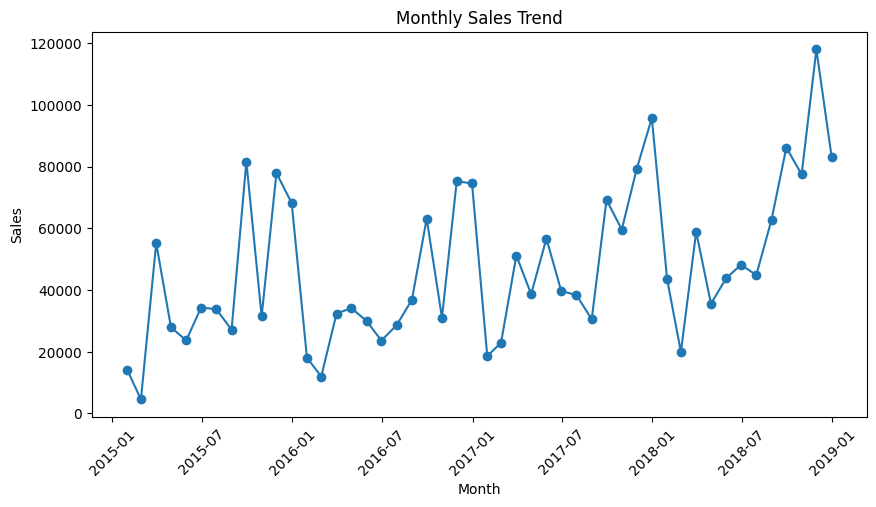

In [3]:
# Sales trend visualize karo
plt.figure(figsize=(10,5))
plt.plot(monthly_sales['Order Date'], monthly_sales['Sales'], marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.show()

In [4]:
from sklearn.linear_model import LinearRegression

# Month ko number mein convert karo (model ko numbers chahiye, dates nahi)
monthly_sales['Month_Number'] = range(len(monthly_sales))

X = monthly_sales[['Month_Number']]
y = monthly_sales['Sales']

model = LinearRegression()
model.fit(X, y)

# Agle 6 months predict karo
future_months = pd.DataFrame({'Month_Number': range(len(monthly_sales), len(monthly_sales) + 6)})
future_predictions = model.predict(future_months)

future_predictions

array([68878.99833333, 69767.31052491, 70655.6227165 , 71543.93490808,
       72432.24709966, 73320.55929124])

/tmp/ipykernel_1040/285806899.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates = pd.date_range(start=last_date, periods=7, freq='M')[1:]


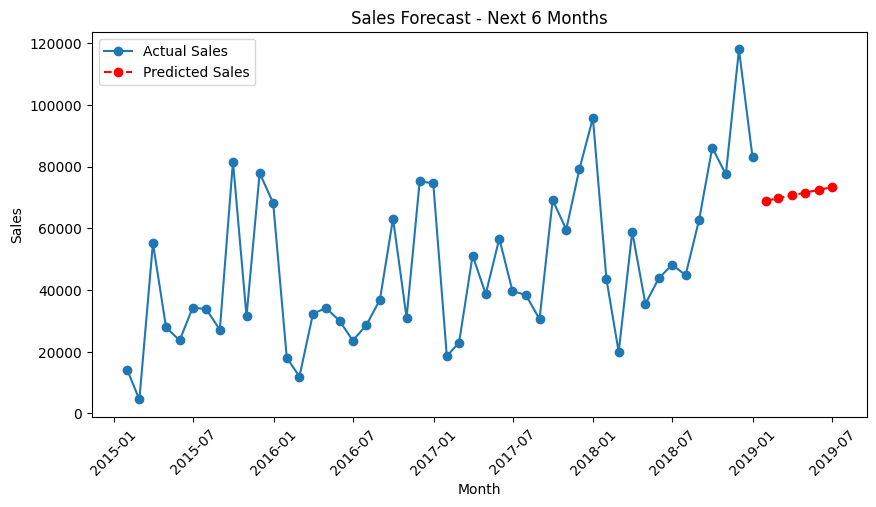

In [5]:
# Future dates banao graph ke liye
last_date = monthly_sales['Order Date'].max()
future_dates = pd.date_range(start=last_date, periods=7, freq='M')[1:]

plt.figure(figsize=(10,5))
plt.plot(monthly_sales['Order Date'], monthly_sales['Sales'], marker='o', label='Actual Sales')
plt.plot(future_dates, future_predictions, marker='o', linestyle='--', color='red', label='Predicted Sales')
plt.title('Sales Forecast - Next 6 Months')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.legend()
plt.xticks(rotation=45)
plt.show()